In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Мы будем работать с данными агрегатора такси [Sigma Cabs](https://www.kaggle.com/datasets/arashnic/taxi-pricing-with-mobility-analytics). В зависимости от характеристик поездки требуется предсказать один из трех типов повышенного ценообразования: [1, 2, 3]. Таким образом, это поможет компании оптимально мэтчить такси и клиентов. 

In [2]:
df = pd.read_csv('data/sigma_cabs.csv')
df.shape

(131662, 14)

In [3]:
# Занесем индекс колонку
df = df.set_index('Trip_ID')
df.head()

,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type
Trip_ID,,,,,,,,,,,,,
T0005689460,6.77,B,1.0,2.42769,A,A,3.90500,0,40.0,46,60,Female,2
T0005689461,29.47,B,10.0,2.78245,B,A,3.45000,0,38.0,56,78,Male,2
T0005689464,41.58,NaN,10.0,NaN,NaN,E,3.50125,2,NaN,56,77,Male,2
T0005689465,61.56,C,10.0,NaN,NaN,A,3.45375,0,NaN,52,74,Male,3
T0005689467,54.95,C,10.0,3.03453,B,A,3.40250,4,51.0,49,102,Male,2


Описание признаков:

1. **Trip_ID**: ID for TRIP
2. **Trip_Distance**: The distance for the trip requested by the customer
3. **TypeofCab**: Category of the cab requested by the customer
4. **CustomerSinceMonths**: Customer using cab services since n months; 0 month means current month
5. **LifeStyleIndex**: Proprietary index created by Sigma Cabs showing lifestyle of the customer based on their behaviour
6. **ConfidenceLifeStyle_Index**: Category showing confidence on the index mentioned above
7. **Destination_Type**: Sigma Cabs divides any destination in one of the 14 categories.
8. **Customer_Rating**: Average of life time ratings of the customer till date
9. **CancellationLast1Month**: Number of trips cancelled by the customer in last 1 month
10. **Var1**, **Var2** and **Var3**: Continuous variables masked by the company. Can be used for modelling purposes
11. **Gender**: Gender of the customer

**SurgePricingType**: Target (can be of 3 types)


### EDA 
Заполните пропуски в вещественных признаках медианой, а в категориальных - самым популярным классом. Изобразите марицу корреляций и выведите топ5 пар самых коррелированных признаков.

Так как в сумме уникальных значений различных категориальных признаков окажется не супер-много, примените `One-Hot-Encoding` для них. Не забудьте в методе `pd.get_dummies` указать параметр `drop_first=True`.

In [4]:
### Your code is here
numerical_columns = df.loc[:, df.dtypes!=object].columns
print(numerical_columns, len(numerical_columns))

categorical_columns = df.loc[:, df.dtypes==object].columns
print(categorical_columns, len(categorical_columns))




Index(['Trip_Distance', 'Customer_Since_Months', 'Life_Style_Index',
       'Customer_Rating', 'Cancellation_Last_1Month', 'Var1', 'Var2', 'Var3',
       'Surge_Pricing_Type'],
      dtype='object') 9
Index(['Type_of_Cab', 'Confidence_Life_Style_Index', 'Destination_Type',
       'Gender'],
      dtype='object') 4


In [5]:
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_columns:
    popular_value = df[col].value_counts().index[0]
    df[col] = df[col].fillna(popular_value)

if df.isna().sum().sum() > 0:
    print(f'пропуски в датасете есть, их {df.isna().sum().sum()} штук')
    print(f'\n{df.isna().sum()}')
else:
    print('пропусков нет')

пропусков нет


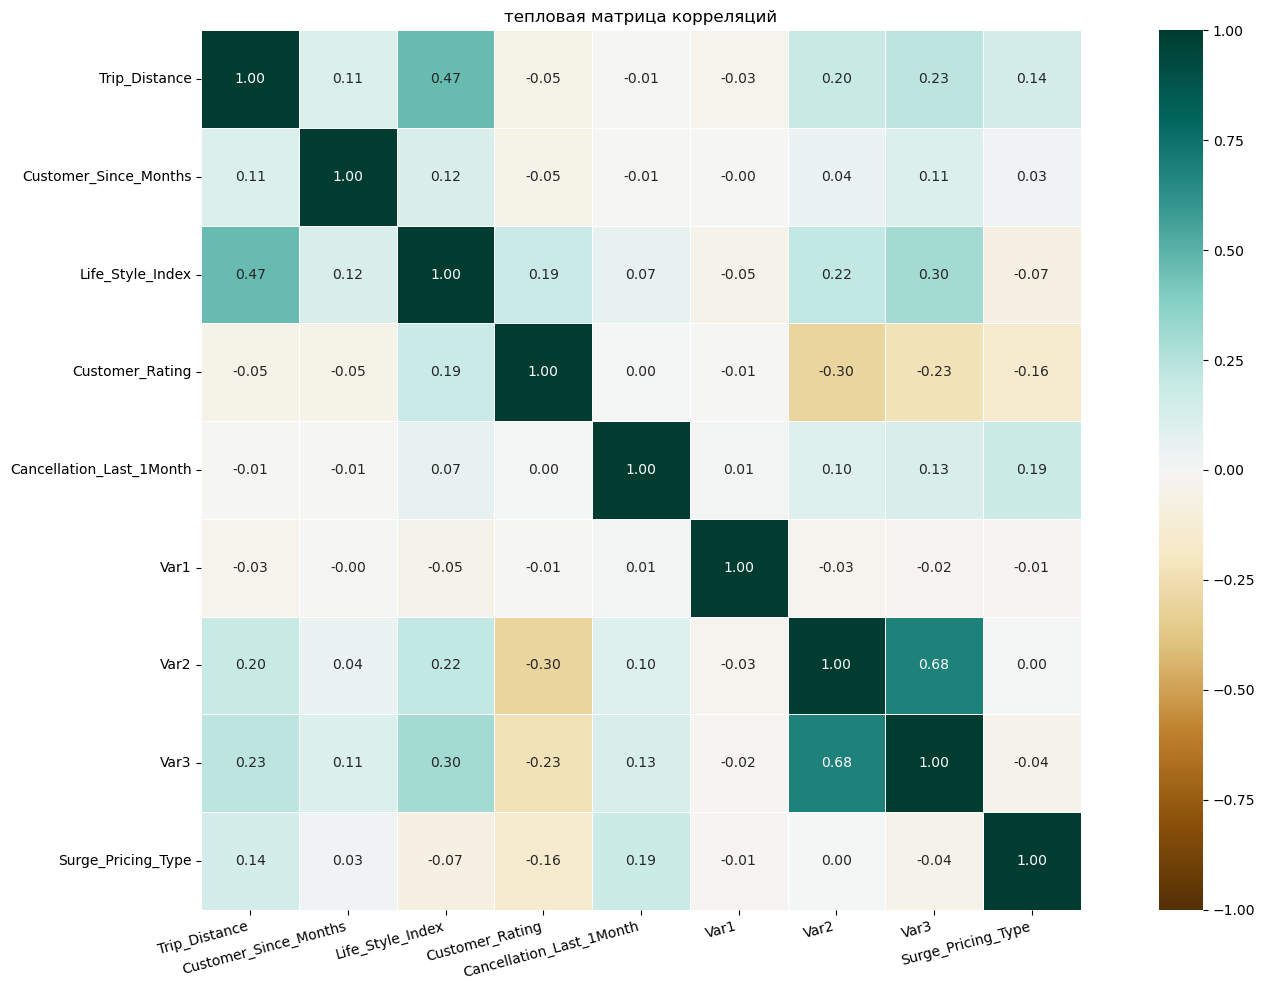

In [6]:
### изобразим матрицу корреляций
import seaborn as sns 
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

sns.heatmap(df[numerical_columns].corr(),
            xticklabels=numerical_columns,
            yticklabels=numerical_columns,
            cmap='BrBG',
            vmin=-1,
            vmax=1,
            annot=True,  
            fmt='.2f',   
            center=0,    
            square=True, 
            linewidths=0.5) 

plt.title('тепловая матрица корреляций')
plt.xticks(rotation=15, ha='right')
plt.yticks()
plt.tight_layout()
plt.show()


In [139]:
### выведем топ 5 пар по корреляции
def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(df[numerical_columns], 5))



Top Absolute Correlations
Var2              Var3                0.683437
Trip_Distance     Life_Style_Index    0.468332
Life_Style_Index  Var3                0.303324
Customer_Rating   Var2                0.302968
Trip_Distance     Var3                0.231706
dtype: float64


In [140]:
### проведем OHE
for col in categorical_columns:
    one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)

df.head()

,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Surge_Pricing_Type,Type_of_Cab_B,...,Destination_Type_F,Destination_Type_G,Destination_Type_H,Destination_Type_I,Destination_Type_J,Destination_Type_K,Destination_Type_L,Destination_Type_M,Destination_Type_N,Gender_Male
Trip_ID,,,,,,,,,,,,,,,,,,,,,
T0005689460,6.77,1.0,2.42769,3.90500,0,40.0,46,60,2,True,...,False,False,False,False,False,False,False,False,False,False
T0005689461,29.47,10.0,2.78245,3.45000,0,38.0,56,78,2,True,...,False,False,False,False,False,False,False,False,False,True
T0005689464,41.58,10.0,2.79805,3.50125,2,61.0,56,77,2,True,...,False,False,False,False,False,False,False,False,False,True
T0005689465,61.56,10.0,2.79805,3.45375,0,61.0,52,74,3,False,...,False,False,False,False,False,False,False,False,False,True
T0005689467,54.95,10.0,3.03453,3.40250,4,51.0,49,102,2,False,...,False,False,False,False,False,False,False,False,False,True


### Training

In [141]:
np.random.seed(2022)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X=df.drop('Surge_Pricing_Type', axis=1)
y=df['Surge_Pricing_Type']

In [142]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, 
                                                     test_size=0.2, 
                                                     shuffle=True, 
                                                     random_state=2022)

**Задание 1.** Обучите One-vs-Rest Logreg. Не забудьте в шаг добавить стандартизацию данных (через `StandardScaler`) Посчитайте precision, recall, f1-score и усредните по всем классам с помощью micro, macro и weighted avg. Здесь и далее округляйте до 3 знака после запятой.

Чтобы отдельно и долго не вычислять метрики, можно воспользоваться `classification_report` из `sklearn.metrics`!

In [143]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

### Your code is here
pipe_one = Pipeline([('scaler', StandardScaler()), 
                     ('one_vs_rest', OneVsRestClassifier(LogisticRegression()))])
pipe_one.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('one_vs_rest',
                 OneVsRestClassifier(estimator=LogisticRegression()))])

In [144]:
from sklearn.metrics import classification_report
y_pred = pipe_one.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           1      0.723     0.542     0.619      5372
           2      0.636     0.834     0.722     11349
           3      0.741     0.571     0.645      9612

    accuracy                          0.679     26333
   macro avg      0.700     0.649     0.662     26333
weighted avg      0.692     0.679     0.673     26333



Подберите оптимальные гиперпараметры модели с помощью `GridSearchCV()` из предложенных. Для лучшего набора гиперпараметров посчитайте те же самые метрики. Валидировать параметры необходимо по `accuracy`. В этот раз проведем настояющую процедуру Кросс-Валидации! 

Для этого в метод `fit` передадим тренировочную часть наших данных, в параметр `cv` ничего не будем передавать (по дефолту 5-fold Кросс-Валидация будет проведена), а итоговые метрики замерим на тесте!

In [145]:
param_grid = {'one_vs_rest__estimator__penalty': ['l1', 'l2', 'elasticnet'],
              'one_vs_rest__estimator__C': [0.001, 0.01, 0.1, 1]}

In [146]:
### Your code is here
from sklearn.model_selection import GridSearchCV

search_cv = GridSearchCV(pipe_one, param_grid)
search_cv.fit(X_train, y_train)

print(f"Best parameter (CV score={search_cv.best_score_:.5f}):")
print(search_cv.best_params_)


Best parameter (CV score=0.68063):
{'one_vs_rest__estimator__C': 0.001, 'one_vs_rest__estimator__penalty': 'l2'}


In [147]:
### Your code is here
y_pred = search_cv.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           1      0.742     0.534     0.621      5372
           2      0.635     0.839     0.723     11349
           3      0.742     0.576     0.649      9612

    accuracy                          0.681     26333
   macro avg      0.706     0.650     0.664     26333
weighted avg      0.696     0.681     0.675     26333



In [148]:
### лучшая модель из GridSearchCV
best_model = search_cv.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           1      0.742     0.534     0.621      5372
           2      0.635     0.839     0.723     11349
           3      0.742     0.576     0.649      9612

    accuracy                          0.681     26333
   macro avg      0.706     0.650     0.664     26333
weighted avg      0.696     0.681     0.675     26333



**Задание 2.** Обучите логистическую регрессию с гиперпараметрами из первого задания на полиномиальных признаках до 4 степени. Сравните метрики с первым заданием.


Пример: Пусть у нас был единственный признак 

$$
d_j = [1, 2, 3, 4]
$$

Тогда полиномиальные признаки до 4 степени от такого будут иметь вид:

$$
d_j^1 = [1, 2, 3, 4]
$$

$$
d_j^2 = [1, 4, 9, 16]
$$

$$
d_j^3 = [1, 8, 27, 64]
$$

$$
d_j^4 = [1, 16, 81, 256]
$$

P.S. Бинарные колонки нет смысла возводить в какие-то степени, поэтому возьмем исключительно вещественные из базовых. 

Для этого можно воспользоваться классическим циклом (или уроком из занятия про `Sberbank Housing Market`). Положите модифицированный датасет в переменную `X_polinomial`!

P.S.S Зачастую еще, создаваю полиномиальные фичи, учитывают "пересечения" признаков, то есть, например, из векторов признаков $d_j, d_i$ генерируют не просто новые степени $d_j^2, d_i^2, d_j^3, d_i^3...$, а еще и признаки вида $d_j \cdot d_i, d_j^2 \cdot d_i, d_j \cdot d_i^2...$, но здесь ограничьтесь просто степенями!

In [149]:
### Создание полиномиальных признаков

X_polinomial = X.copy()


### Your code is here
for col in numerical_columns.drop('Surge_Pricing_Type'):
    for power in range(4):
        to_add = (X_polinomial[col]**power).to_frame().rename({col:f"{col}_{power}"}, axis=1)
        X_polinomial = pd.concat((X_polinomial, to_add), axis=1)
X_polinomial.head()

,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Type_of_Cab_B,Type_of_Cab_C,...,Var1_2,Var1_3,Var2_0,Var2_1,Var2_2,Var2_3,Var3_0,Var3_1,Var3_2,Var3_3
Trip_ID,,,,,,,,,,,,,,,,,,,,,
T0005689460,6.77,1.0,2.42769,3.90500,0,40.0,46,60,True,False,...,1600.0,64000.0,1,46,2116,97336,1,60,3600,216000
T0005689461,29.47,10.0,2.78245,3.45000,0,38.0,56,78,True,False,...,1444.0,54872.0,1,56,3136,175616,1,78,6084,474552
T0005689464,41.58,10.0,2.79805,3.50125,2,61.0,56,77,True,False,...,3721.0,226981.0,1,56,3136,175616,1,77,5929,456533
T0005689465,61.56,10.0,2.79805,3.45375,0,61.0,52,74,False,True,...,3721.0,226981.0,1,52,2704,140608,1,74,5476,405224
T0005689467,54.95,10.0,3.03453,3.40250,4,51.0,49,102,False,True,...,2601.0,132651.0,1,49,2401,117649,1,102,10404,1061208


In [163]:
### 

numerical_columns_pol = X_polinomial.loc[:, X_polinomial.dtypes!=object].columns

### выведем топ 5 пар по корреляции
def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(X_polinomial[numerical_columns_pol], 50))




Top Absolute Correlations
Life_Style_Index            Life_Style_Index_1            1.000000
Cancellation_Last_1Month    Cancellation_Last_1Month_1    1.000000
Var1                        Var1_1                        1.000000
Customer_Since_Months       Customer_Since_Months_1       1.000000
Var2                        Var2_1                        1.000000
Customer_Rating             Customer_Rating_1             1.000000
Var3                        Var3_1                        1.000000
Trip_Distance               Trip_Distance_1               1.000000
Life_Style_Index            Life_Style_Index_2            0.997432
Life_Style_Index_1          Life_Style_Index_2            0.997432
Life_Style_Index_2          Life_Style_Index_3            0.997235
Var2_1                      Var2_2                        0.996186
Var2                        Var2_2                        0.996186
Var2_2                      Var2_3                        0.994737
Var3_1                      Var3_2  

In [150]:
X_pol_train, X_pol_test, y_train, y_test  = train_test_split(X_polinomial, y, 
                                                             test_size=0.2, 
                                                             shuffle=True, 
                                                             random_state=2022)

In [151]:
### Your code is here

search_cv = GridSearchCV(pipe_one, param_grid)
search_cv.fit(X_pol_train, y_train)
best_model = search_cv.best_estimator_
y_pred = best_model.predict(X_pol_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           1      0.751     0.533     0.623      5372
           2      0.637     0.835     0.723     11349
           3      0.740     0.587     0.655      9612

    accuracy                          0.683     26333
   macro avg      0.709     0.652     0.667     26333
weighted avg      0.698     0.683     0.678     26333



По аналогии с первым заданием изобразите три калибровочные кривые. Стало ли лучше?

**Задание 3.** Обучите на датасете без полиномиальных признаков One-vs-One `SGDClassifier` из `sklearn.linear_model`, который использует стохастический градиентный спуск (узнаете о нем позже) и может обучать как `SVM`, так и, например, `LogReg`, если указать в качестве параметра `loss` либо `hinge`, либо `log` соответственно!

Посчитайте precision, recall, f1-score и усредните по всем классам с помощью micro, macro и weighted avg.

In [152]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, 
                                                     test_size=0.2, 
                                                     shuffle=True, 
                                                     random_state=2022)

In [153]:
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsOneClassifier

### Your code is here

pipe_one_vs_one = Pipeline([('scaler', StandardScaler()),
                            ('one_vs_one', OneVsOneClassifier(SGDClassifier()))])
pipe_one_vs_one.fit(X_train, y_train)
print(pipe_one_vs_one.score(X_test, y_test))

0.676717426802871


In [154]:
y_pred = pipe_one_vs_one.predict(X_test)
report = classification_report(y_test, y_pred, digits=3, output_dict=True)

print(classification_report(y_test, y_pred, digits=3))

# Recall для класса 1
recall_class_1 = report['1']['recall']
print(f"Recall для класса 1: {recall_class_1:.3f}")

              precision    recall  f1-score   support

           1      0.748     0.521     0.614      5372
           2      0.626     0.870     0.728     11349
           3      0.756     0.536     0.627      9612

    accuracy                          0.677     26333
   macro avg      0.710     0.642     0.656     26333
weighted avg      0.698     0.677     0.668     26333

Recall для класса 1: 0.521


In [155]:
from sklearn.metrics import precision_score, recall_score, f1_score


# Macro averaging
print(f"Precision macro: {precision_score(y_test, y_pred, average='macro'):.3f}")
print(f"Recall macro: {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"F1 macro: {f1_score(y_test, y_pred, average='macro'):.3f}")

# Micro averaging  
print(f"Precision micro: {precision_score(y_test, y_pred, average='micro'):.3f}")
print(f"Recall micro: {recall_score(y_test, y_pred, average='micro'):.3f}")
print(f"F1 micro: {f1_score(y_test, y_pred, average='micro'):.3f}")

# Weighted averaging
print(f"Precision weighted: {precision_score(y_test, y_pred, average='weighted'):.3f}")
print(f"Recall weighted: {recall_score(y_test, y_pred, average='weighted'):.3f}")
print(f"F1 weighted: {f1_score(y_test, y_pred, average='weighted'):.3f}")



Precision macro: 0.710
Recall macro: 0.642
F1 macro: 0.656
Precision micro: 0.677
Recall micro: 0.677
F1 micro: 0.677
Precision weighted: 0.698
Recall weighted: 0.677
F1 weighted: 0.668


Подберите оптимальные гиперпараметры модели с помощью `GridSearchCV()`. При этом переберите всевозможные функции потерь. Таким образом, при `loss = 'hinge'`, мы обучим SVM, при `loss = 'log'` мы обучим логистическую регрессию и т.д.

Используйте прием с Кросс-Валидацией при подборе параметров, как ранее, а также замерьте метрики на тесте.

In [156]:
param_grid = {'one_vs_one__estimator__loss': ['hinge', 'log', 'modified_huber'],
              'one_vs_one__estimator__penalty': ['l1', 'l2'],
              'one_vs_one__estimator__alpha': [0.001, 0.01, 0.1]}

In [157]:
### Your code is here
search_cv_one_one = GridSearchCV(pipe_one_vs_one, param_grid)
search_cv_one_one.fit(X_train, y_train)

print(f"Best parameter (CV score={search_cv_one_one.best_score_:.5f}):")
print(search_cv_one_one.best_params_)

y_pred_1 = search_cv_one_one.predict(X_test)
print(classification_report(y_test, y_pred_1, digits=3))

best_model = search_cv_one_one.best_estimator_
y_pred_2 = best_model.predict(X_test)
print(classification_report(y_test, y_pred_2, digits=3))

Best parameter (CV score=0.68071):
{'one_vs_one__estimator__alpha': 0.1, 'one_vs_one__estimator__loss': 'hinge', 'one_vs_one__estimator__penalty': 'l2'}
              precision    recall  f1-score   support

           1      0.756     0.517     0.615      5372
           2      0.625     0.876     0.730     11349
           3      0.762     0.535     0.628      9612

    accuracy                          0.678     26333
   macro avg      0.714     0.643     0.658     26333
weighted avg      0.702     0.678     0.669     26333

              precision    recall  f1-score   support

           1      0.756     0.517     0.615      5372
           2      0.625     0.876     0.730     11349
           3      0.762     0.535     0.628      9612

    accuracy                          0.678     26333
   macro avg      0.714     0.643     0.658     26333
weighted avg      0.702     0.678     0.669     26333



Можно ли однозначно сказать, какой подход оказался лучше: One-vs-Rest или One-vs-One?